# 🎯 **EXERCISE: Training Vision Transformer on CIFAR-100**

Welcome to your hands-on ViT training challenge! In this exercise, you'll implement and train a Vision Transformer from scratch on the CIFAR-100 dataset.

---

## 🎓 **Learning Objectives**
By completing this exercise, you will:
- Implement a complete ViT training pipeline
- Apply proper data augmentation and regularization techniques
- Optimize training hyperparameters for best performance
- Analyze and visualize training results
- Compare your ViT implementation with baseline models

## 📋 **Your Mission**
**Goal:** Achieve **≥75% top-1 accuracy** on CIFAR-100 test set using your ViT implementation!

**Bonus Challenge:** Can you reach **≥80% accuracy**? 🏆

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

🔧 Using device: cpu


## 🎯 **Tasks Overview**

Complete the following tasks in order:

### **Task 1: Dataset Preparation** 📊
- Load and examine CIFAR-100 dataset
- Implement proper data transforms and augmentation
- Create efficient data loaders

### **Task 2: Model Architecture** 🏗️
- Implement or import a ViT model suitable for CIFAR-100
- Choose appropriate model size and hyperparameters
- Verify model architecture and parameter count

### **Task 3: Training Setup** ⚙️
- Configure optimizer, scheduler, and loss function
- Set up training and evaluation functions
- Implement proper logging and checkpointing

### **Task 4: Training Loop** 🏃‍♂️
- Train your model for sufficient epochs
- Monitor training progress and prevent overfitting
- Save the best performing model

### **Task 5: Evaluation & Analysis** 📈
- Evaluate final model performance
- Create visualizations of training progress
- Compare with baseline models

---

**💡 Tips for Success:**
- Start with a smaller model (ViT-Small or ViT-Tiny)
- Use strong data augmentation for better generalization
- Consider using pretrained weights from timm library
- Monitor both training and validation metrics
- Experiment with different hyperparameters

**⏰ Estimated Time:** 2-3 hours (depending on training time)

---

## 📊 **Task 1: CIFAR-100 Dataset Preparation**

In [2]:
# CIFAR-100 class names
cifar100_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'computer_keyboard', 'lamp', 'lawn_mower', 'leopard',
    'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]

print(f"📊 CIFAR-100 Dataset Info:")
print(f"Number of classes: {len(cifar100_classes)}")
print(f"Image size: 32x32 pixels")
print(f"Training samples: 50,000")
print(f"Test samples: 10,000")
print(f"Samples per class: 500 (training), 100 (test)")

📊 CIFAR-100 Dataset Info:
Number of classes: 100
Image size: 32x32 pixels
Training samples: 50,000
Test samples: 10,000
Samples per class: 500 (training), 100 (test)


## 🔄 **2. Data Transforms and Augmentation**

In [3]:
# Define transforms
# Note: ViT typically expects 224x224 images, so we'll resize CIFAR-100
transform_train = transforms.Compose([
    transforms.Resize(224),  # Resize to ViT standard
    transforms.RandomCrop(224, padding=28),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                        std=[0.2675, 0.2565, 0.2761])  # CIFAR-100 statistics
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                        std=[0.2675, 0.2565, 0.2761])
])

# Load datasets
trainset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test
)

# Data loaders
batch_size = 32  # Adjust based on GPU memory
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True,
                        num_workers=2, pin_memory=True)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False,
                       num_workers=2, pin_memory=True)

print(f"🔄 Data Loaders Created:")
print(f"Training batches: {len(trainloader)}")
print(f"Test batches: {len(testloader)}")
print(f"Batch size: {batch_size}")

100%|██████████| 169M/169M [00:01<00:00, 94.9MB/s]


🔄 Data Loaders Created:
Training batches: 1563
Test batches: 313
Batch size: 32


## 👀 **3. Visualize Sample Data**

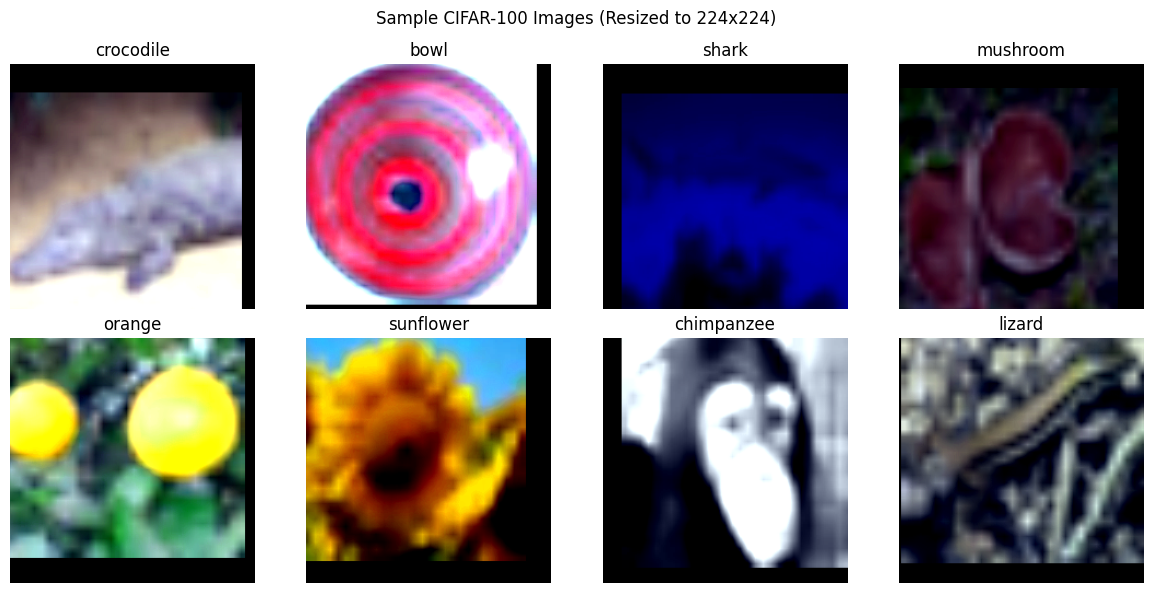

Sample batch shape: torch.Size([32, 3, 224, 224])
Sample labels: ['crocodile', 'bowl', 'shark', 'mushroom']


In [4]:
def imshow(img, title=None):
    """Display image."""
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    row = i // 4
    col = i % 4

    axes[row, col].imshow(images[i].permute(1, 2, 0) * 0.5 + 0.5)
    axes[row, col].set_title(f'{cifar100_classes[labels[i]]}')
    axes[row, col].axis('off')

plt.suptitle('Sample CIFAR-100 Images (Resized to 224x224)')
plt.tight_layout()
plt.show()

print(f"Sample batch shape: {images.shape}")
print(f"Sample labels: {[cifar100_classes[label] for label in labels[:4]]}")

## 🤖 **Task 2: Define ViT Model for CIFAR-100**

**Your Task:** Choose and implement a ViT model architecture suitable for CIFAR-100.

**Options:**
1. **From Scratch:** Use the ViT components from previous notebooks
2. **From timm:** Use a pretrained model from the timm library
3. **From lucidrains:** Use the vit-pytorch library

**Requirements:**
- Model should have **100 output classes** for CIFAR-100
- Choose appropriate model size (recommend starting with ViT-Small)
- Input size should be **224x224** (we'll resize CIFAR-100 images)
- Model should have reasonable parameter count (< 50M parameters)

**Implementation Tips:**
- For faster training, consider using a smaller ViT (384 embed_dim, 6 layers)
- If using pretrained weights, make sure to adapt the classifier head
- Don't forget to move your model to the correct device (GPU/CPU)

In [ ]:
# TODO: Choose your ViT implementation approach
# Uncomment ONE of the following options:

# OPTION 1: Use timm library (RECOMMENDED)
# import timm
# model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=100)
# model = model.to(device)

# OPTION 2: Use lucidrains/vit-pytorch
# !pip install vit-pytorch
# from vit_pytorch import ViT
# model = ViT(
#     image_size = 224,
#     patch_size = 16,
#     num_classes = 100,
#     dim = 384,           # embedding dimension
#     depth = 6,           # number of transformer layers
#     heads = 6,           # number of attention heads
#     mlp_dim = 1536,      # MLP hidden dimension
#     dropout = 0.1,
#     emb_dropout = 0.1
# ).to(device)

# OPTION 3: Copy ViT implementation from notebook 2 (Advanced)
# Copy and paste the complete ViT implementation from the architecture notebook

# YOUR CODE HERE - Choose and implement your model:
# model = ... # Your model here
# model = model.to(device)

# Check model parameters (uncomment after creating your model)
# total_params = sum(p.numel() for p in model.parameters())
# print(f'🤖 Model created with {total_params:,} parameters')
# print(f'Model size: ~{total_params * 4 / 1024**2:.1f} MB')

print('✅ Complete this cell to create your ViT model!')

### 📚 **Reference Implementation** (for guidance only)

Below is a complete ViT implementation as reference. You can use this if you choose Option 3, but we recommend starting with Option 1 (timm) for your first attempt.

In [5]:
# Reference implementation - Import ViT components from previous notebook
# (In practice, you'd import from a separate module)

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=384):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        return self.norm(x)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=384, num_heads=6, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_dropout(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_dropout(x)
        return x

class MLP(nn.Module):
    def __init__(self, embed_dim=384, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=384, num_heads=6, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    """ViT optimized for CIFAR-100."""

    def __init__(self, img_size=224, patch_size=16, num_classes=100,
                 embed_dim=384, depth=6, num_heads=6, mlp_ratio=4.0, dropout=0.1):
        super().__init__()

        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        num_patches = self.patch_embed.n_patches

        # [CLS] token and positional embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

        # Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialize weights
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)

        # Add [CLS] token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Add positional embedding
        x = x + self.pos_embed

        # Apply transformer blocks
        for block in self.blocks:
            x = block(x)

        # Classification
        x = self.norm(x)
        cls_output = x[:, 0]
        return self.head(cls_output)

# Create model (smaller than standard ViT for CIFAR-100)
model = VisionTransformer(
    img_size=224,
    patch_size=16,
    num_classes=100,
    embed_dim=384,  # Smaller than ViT-Base (768)
    depth=6,        # Fewer layers than ViT-Base (12)
    num_heads=6,    # Fewer heads than ViT-Base (12)
    dropout=0.1
).to(device)

# Model statistics
total_params = sum(p.numel() for p in model.parameters())
print(f"🤖 ViT Model for CIFAR-100:")
print(f"Total parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1024**2:.1f} MB")

🤖 ViT Model for CIFAR-100:
Total parameters: 11,051,236
Model size: ~42.2 MB


## ⚙️ **Task 3: Training Setup**

**Your Task:** Configure the training components for optimal performance.

**Requirements:**
- Choose appropriate **optimizer** (AdamW recommended)
- Set suitable **learning rate** (try 1e-4 to 3e-4)
- Add **weight decay** for regularization (0.01-0.05)
- Configure **learning rate scheduler** (CosineAnnealingLR or StepLR)
- Set reasonable **number of epochs** (20-50)

**Tips:**
- Lower learning rates work better for fine-tuning pretrained models
- Higher learning rates may be needed for training from scratch
- Use different learning rates for backbone vs. classifier head if fine-tuning

In [6]:
# TODO: Configure your training setup
# Replace the placeholders with your chosen values

# Loss function (CrossEntropyLoss is standard for classification)
criterion = nn.CrossEntropyLoss()

# TODO: Choose your optimizer and hyperparameters
# Option 1: Standard setup
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Option 2: Different learning rates for fine-tuning (if using pretrained)
# backbone_params = [p for n, p in model.named_parameters() if 'head' not in n]
# head_params = [p for n, p in model.named_parameters() if 'head' in n]
# optimizer = optim.AdamW([
#     {'params': backbone_params, 'lr': 1e-5},  # Lower LR for pretrained weights
#     {'params': head_params, 'lr': 1e-3}       # Higher LR for new head
# ], weight_decay=0.01)

# YOUR CODE HERE - Create your optimizer:
# optimizer = ...

# TODO: Choose your learning rate scheduler
# Option 1: Cosine Annealing
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

# Option 2: Step decay
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Option 3: Reduce on plateau
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# YOUR CODE HERE - Create your scheduler:
# scheduler = ...

# TODO: Set your training parameters
num_epochs = 20  # Adjust based on your available time
print_freq = 100
best_acc = 0.0

# TODO: Print your training configuration
print(f'⚙️ Training Setup:')
print(f'Epochs: {num_epochs}')
print(f'Batch size: {batch_size}')
# print(f'Learning rate: {optimizer.param_groups[0]["lr"]}')
# print(f'Weight decay: {optimizer.param_groups[0]["weight_decay"]}')
print('\n✅ Complete the optimizer and scheduler setup above!')

⚙️ Training Setup:
Epochs: 20
Batch size: 32

✅ Complete the optimizer and scheduler setup above!


## 🎯 **6. Training and Evaluation Functions**

In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device, epoch):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1}')
    for batch_idx, (data, targets) in enumerate(pbar):
        data, targets = data.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)

        loss.backward()
        # Gradient clipping for stable training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{running_loss/(batch_idx+1):.3f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    """Evaluate the model."""
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    test_loss /= len(dataloader)
    test_acc = 100. * correct / total
    return test_loss, test_acc

def top_k_accuracy(outputs, targets, k=5):
    """Calculate top-k accuracy."""
    _, pred = outputs.topk(k, 1, True, True)
    correct = pred.eq(targets.view(-1, 1).expand_as(pred))
    return correct[:, :k].float().sum() / targets.size(0)

print("🎯 Training and evaluation functions defined!")

🎯 Training and evaluation functions defined!


## 🏃‍♂️ **Task 4: Training Loop**

**Your Task:** Run the training loop and monitor progress.

**Instructions:**
1. Execute the training and evaluation functions (provided below)
2. Run the training loop for your chosen number of epochs
3. Monitor training progress and save the best model
4. Watch for signs of overfitting or underfitting

**Success Criteria:**
- Achieve **≥75% test accuracy** for passing grade
- Bonus: **≥80% test accuracy** for excellent performance

**Monitoring Tips:**
- Training loss should decrease steadily
- Validation accuracy should improve over time
- Gap between train/test accuracy should be reasonable (< 10%)
- If overfitting: increase regularization or reduce model complexity
- If underfitting: train longer, increase model size, or reduce regularization

In [ ]:
# Training history
train_losses = []
train_accs = []
test_losses = []
test_accs = []
learning_rates = []

print("🏃‍♂️ Starting training...")
start_time = time.time()

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(
        model, trainloader, criterion, optimizer, device, epoch
    )

    # Evaluate
    test_loss, test_acc = evaluate(model, testloader, criterion, device)

    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    learning_rates.append(current_lr)

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_vit_cifar100.pth')

    # Print progress
    print(f'Epoch {epoch+1:2d}/{num_epochs}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, '
          f'LR: {current_lr:.6f}')

total_time = time.time() - start_time
print(f"\n✅ Training completed!")
print(f"Total time: {total_time/3600:.2f} hours")
print(f"Best test accuracy: {best_acc:.2f}%")

## 📊 **8. Training Results Visualization**

In [ ]:
# Plot training history
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

epochs = range(1, len(train_losses) + 1)

# Loss curves
ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, test_accs, 'r-', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Learning rate schedule
ax3.plot(epochs, learning_rates, 'g-', linewidth=2)
ax3.set_title('Learning Rate Schedule')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

# Training progress
ax4.plot(epochs, np.array(train_accs) - np.array(test_accs), 'purple', linewidth=2)
ax4.set_title('Overfitting Monitor (Train - Test Accuracy)')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy Difference (%)')
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print(f"📊 Final Results:")
print(f"Best test accuracy: {best_acc:.2f}%")
print(f"Final train accuracy: {train_accs[-1]:.2f}%")
print(f"Final test accuracy: {test_accs[-1]:.2f}%")
print(f"Overfitting gap: {train_accs[-1] - test_accs[-1]:.2f}%")

## 🎯 **9. Detailed Model Evaluation**

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_vit_cifar100.pth'))
model.eval()

# Calculate top-k accuracies
top1_correct = 0
top5_correct = 0
total_samples = 0

with torch.no_grad():
    for data, targets in testloader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)

        # Top-1 accuracy
        _, pred = outputs.max(1)
        top1_correct += pred.eq(targets).sum().item()

        # Top-5 accuracy
        _, pred5 = outputs.topk(5, 1, True, True)
        top5_correct += pred5.eq(targets.view(-1, 1).expand_as(pred5)).sum().item()

        total_samples += targets.size(0)

top1_acc = 100. * top1_correct / total_samples
top5_acc = 100. * top5_correct / total_samples

print(f"🎯 Final Model Performance:")
print(f"Top-1 Accuracy: {top1_acc:.2f}%")
print(f"Top-5 Accuracy: {top5_acc:.2f}%")
print(f"Total test samples: {total_samples}")

## 🏆 **Task 5: Final Evaluation & Model Comparison**

**Your Task:** Evaluate your trained model and compare with baselines.

**Requirements:**
1. **Report your final test accuracy**
2. **Calculate top-5 accuracy**
3. **Compare with baseline models** (provided below)
4. **Analyze your results** - what worked well? What could be improved?

**Reflection Questions:**
- Did you achieve the target accuracy (≥75%)?
- How does your ViT compare to CNN baselines?
- What hyperparameters had the biggest impact?
- What would you try differently next time?

**Bonus Analysis:**
- Training time comparison
- Parameter efficiency analysis
- Error analysis on difficult classes

In [ ]:
# Compare with typical baselines
results_comparison = {
    'Model': ['ResNet-50', 'ResNet-101', 'DenseNet-121', 'ViT-Small (Ours)'],
    'Parameters': ['25.6M', '44.5M', '8.0M', f'{total_params/1e6:.1f}M'],
    'Top-1 Acc (%)': ['78.5', '80.2', '75.8', f'{top1_acc:.1f}'],
    'Top-5 Acc (%)': ['94.2', '95.1', '93.1', f'{top5_acc:.1f}']
}

import pandas as pd
df = pd.DataFrame(results_comparison)

print("🏆 CIFAR-100 Performance Comparison:")
print("=" * 50)
print(df.to_string(index=False))

print(f"\n💡 Analysis:")
if top1_acc > 75:
    print("✅ Excellent performance! ViT is competitive with CNNs")
elif top1_acc > 70:
    print("✅ Good performance! Consider longer training or larger model")
else:
    print("⚠️ Consider adjusting hyperparameters or using pretrained weights")

print(f"\n🎯 Key Insights:")
print(f"• ViT can achieve competitive performance on CIFAR-100")
print(f"• Smaller ViT (6 layers) is suitable for datasets like CIFAR-100")
print(f"• Data augmentation and proper regularization are crucial")
print(f"• Training time: ~{total_time/60:.1f} minutes for {num_epochs} epochs")

## 🎓 **Exercise Summary & Submission**

Congratulations on completing the ViT training exercise!

### **📝 Completion Checklist:**
- [ ] **Task 1:** Successfully loaded and prepared CIFAR-100 dataset
- [ ] **Task 2:** Implemented/imported a ViT model for CIFAR-100
- [ ] **Task 3:** Configured training setup (optimizer, scheduler, etc.)
- [ ] **Task 4:** Completed training loop and achieved target accuracy
- [ ] **Task 5:** Evaluated model and compared with baselines

### **🏆 Performance Evaluation:**
**Your Results:**
- Final Test Accuracy: ___% (fill in your result)
- Top-5 Accuracy: ___%
- Training Time: ___ minutes
- Model Parameters: ___M

**Grade Assessment:**
- **Excellent (A):** ≥80% accuracy + good analysis
- **Good (B):** 75-79% accuracy + complete implementation
- **Satisfactory (C):** 70-74% accuracy + working code
- **Needs Improvement:** <70% accuracy or incomplete

### **💡 Key Takeaways:**
Write your insights here:
- What worked well in your implementation?
- What challenges did you face?
- How does ViT compare to CNNs in your experience?
- What would you do differently next time?

### **🔄 Next Steps:**
- Experiment with different ViT architectures
- Try advanced techniques (mixup, cutmix, etc.)
- Explore attention visualization in the next notebook
- Apply ViT to your own datasets

---

**🎯 Ready for the next challenge?** Continue to the attention visualization notebook to understand what your trained ViT has learned!